# Circuits for Lesson 13 of the Tutorial

The 19 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 13 of the Tutorial*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# On Google Colab the package is not installed yet; install it there.
# A local Jupyter already has it: pip install symbulator[notebook]
import sys
if "google.colab" in sys.modules:
    %pip install -q symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.17'

## 1. AS7's Example 19.1 (z parameters)

In this problem, we find a two-port equivalent for the first time. Determine the z parameters of the T network between nodes 1 and 3: z11 = 60, z12 = z21 = 40, z22 = 70.

![The circuit of AS7's Example 19.1 (z parameters)](https://learn.symbulator.com/assets/circuit/as7e1901.png)

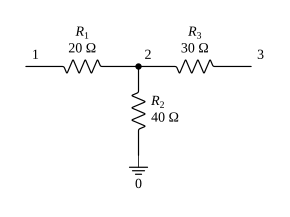

In [3]:
c1 = '''
r1,1,2,20
r2,2,0,40
r3,2,3,30
'''
draw(c1)

In [4]:
r1 = port(c1, '1', '3', 'z', domain='dc')
r1

PortResult('z', 11=60, 12=40, 21=40, 22=70)

## 2. AS7's Example 19.2 (a two-port as an element)

In this problem, we use a two-port as an element for the first time, with its four parameters riding in the description's fourth term (z,1,2,[40,20j,30j,50] — the order is 11, 12, 21, 22). Find I1 and I2 — aa(iz1) and aa(iz2).

![The circuit of AS7's Example 19.2 (a two-port as an element)](https://learn.symbulator.com/assets/circuit/as7e1902.png)

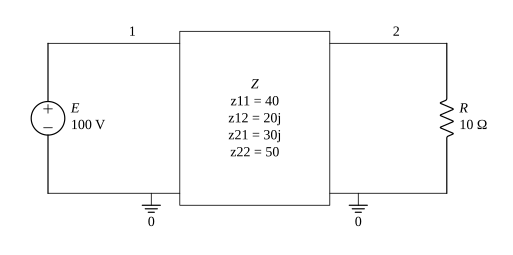

In [5]:
c2 = '''
e,1,0,100
z,1,2,[40,20j,30j,50]
r,2,0,10
'''
draw(c2)

In [6]:
r2 = ac(c2, omega='omega')
r2.rounded(4)

Result(domain='ac')
  ap_e = -100
  ap_r = 5
  i_e = -2
  i_r = 1.0*I
  i_z1 = 2
  i_z2 = -1.0*I
  p_e = -100
  p_r = 5
  q_e = 0
  q_r = 0
  s_e = -100
  s_r = 5
  v_1 = 100
  v_2 = 10.0*I
  v_e = 100
  v_r = 10.0*I
  z_e = 50

## 3. AS7's Example 19.3 (y parameters)

Obtain the y parameters between nodes 1 and 2: 3/4, -1/2, -1/2 and 5/8.

![The circuit of AS7's Example 19.3 (y parameters)](https://learn.symbulator.com/assets/circuit/as7e1903.png)

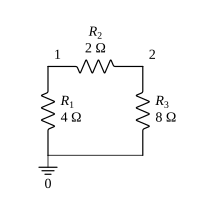

In [7]:
c3 = '''
r1,1,0,4
r2,1,2,2
r3,2,0,8
'''
draw(c3)

In [8]:
r3 = port(c3, '1', '2', 'y', domain='dc')
r3

PortResult('y', 11=3/4, 12=-1/2, 21=-1/2, 22=5/8)

## 4. AS7's Example 19.4 (y parameters around a dependent source)

Determine the y parameters of the two-port with a dependent source inside. A two-port equivalent works perfectly well around a controlled source.

![The circuit of AS7's Example 19.4 (y parameters around a dependent source)](https://learn.symbulator.com/assets/circuit/as7e1904.png)

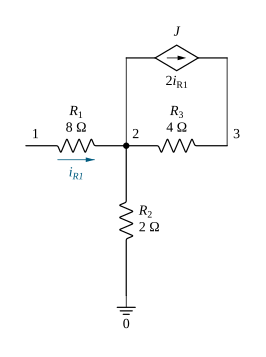

In [9]:
c4 = '''
r1,1,2,8
r2,2,0,2
r3,2,3,4
j,2,3,2*ir1
'''
draw(c4)

In [10]:
r4 = port(c4, '1', '3', 'y', domain='dc')
r4

PortResult('y', 11=3/20, 12=-1/20, 21=-1/4, 22=1/4)

## 5. AS7's Example 19.5 (h parameters)

Find the hybrid (h) parameters between nodes 1 and 3: 4, 2/3, -2/3 and 1/9.

![The circuit of AS7's Example 19.5 (h parameters)](https://learn.symbulator.com/assets/circuit/as7e1905.png)

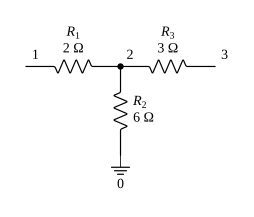

In [11]:
c5 = '''
r1,1,2,2
r2,2,0,6
r3,2,3,3
'''
draw(c5)

In [12]:
r5 = port(c5, '1', '3', 'h', domain='dc')
r5

PortResult('h', 11=4, 12=2/3, 21=-2/3, 22=1/9)

## 6. AS7's Example 19.6 (Thevenin at the output port)

Find the Thévenin equivalent at the output port of a circuit built around an h-parameter two-port. The parameters ride in the description's fourth term, so they reach the equivalent tool like any other value and the answers come straight back as numbers: vth = -29.69 V, req = 51.46 ohm. (Leave the fourth term off and the same run answers with formulas in the four parameters instead.)

![The circuit of AS7's Example 19.6 (Thevenin at the output port)](https://learn.symbulator.com/assets/circuit/as7e1906.png)

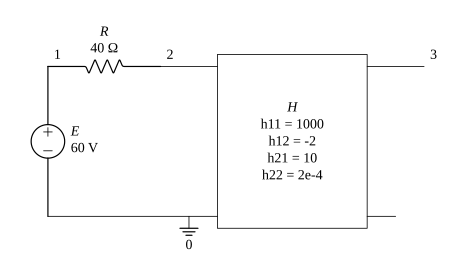

In [13]:
c6 = '''
e,1,0,60
r,1,2,40
h,2,3,[1000,-2,10,2e-4]
'''
draw(c6)

In [14]:
r6 = th(c6, '3', '0', domain='dc')
r6

TheveninResult(domain='dc', vth=-29.6912114014252, ino=-0.576923076923077, req=51.4647664291370, pmax=4.28238625982094)

## 7. AS7's Example 19.7 (g parameters in s)

Find the g parameters as functions of s — the same two-port equivalent, run in FD.

![The circuit of AS7's Example 19.7 (g parameters in s)](https://learn.symbulator.com/assets/circuit/as7e1907.png)

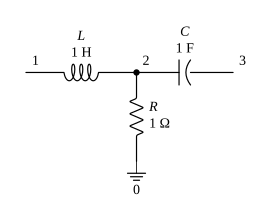

In [15]:
c7 = '''
l,1,2,1
r,2,0,1
c,2,3,1
'''
draw(c7)

In [16]:
r7 = port(c7, '1', '3', 'g', domain='fd')
r7

PortResult('g', 11=1/(s + 1), 12=-1/(s + 1), 21=1/(s + 1), 22=(s**2 + s + 1)/(s*(s + 1)))

## 8. AS7's Practice Problem 19.7 (a ladder in s)

Determine the g parameters of the ladder network in the s domain.

![The circuit of AS7's Practice Problem 19.7 (a ladder in s)](https://learn.symbulator.com/assets/circuit/as7pp1907.png)

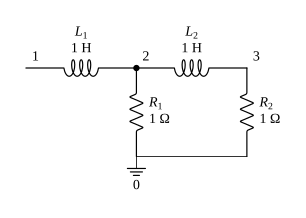

In [17]:
c8 = '''
l1,1,2,1
r1,2,0,1
l2,2,3,1
r2,3,0,1
'''
draw(c8)

In [18]:
r8 = port(c8, '1', '3', 'g', domain='fd')
r8

PortResult('g', 11=(s + 2)/(s**2 + 3*s + 1), 12=-1/(s**2 + 3*s + 1), 21=1/(s**2 + 3*s + 1), 22=s*(s + 2)/(s**2 + 3*s + 1))

## 9. AS7's Example 19.8 (transmission parameters)

Find the transmission (a) parameters of the two-port with the dependent source: 1.765, 15.29, 0.0588 and 1.176.

![The circuit of AS7's Example 19.8 (transmission parameters)](https://learn.symbulator.com/assets/circuit/as7e1908.png)

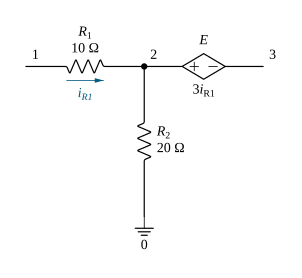

In [19]:
c9 = '''
r1,1,2,10
r2,2,0,20
e,2,3,3*ir1
'''
draw(c9)

In [20]:
r9 = port(c9, '1', '3', 'a', domain='dc')
r9

PortResult('a', 11=30/17, 12=260/17, 21=1/17, 22=20/17)

## 10. Gain Example 1 (the gain tool)

Find Gv, Gi, Gp and Zin for the loaded y-parameter two-port: 55.56, -9.615, 534.2 and 3.462 ohm. The parameters ride in the description; the gains come from the gain mini-tool, given v1, iy1, v2 and iy2 -- not something an input file can carry, so they are recorded here. The source is 1 V because its value cancels out of a gain.

![The circuit of Gain Example 1 (the gain tool)](https://learn.symbulator.com/assets/circuit/gain-example-1.png)

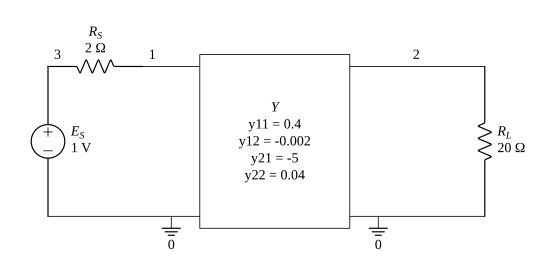

In [21]:
c10 = '''
es,3,0,1
rs,3,1,2
rl,2,0,20
y,1,2,[0.4,-0.002,-5,0.04]
'''
draw(c10)

In [22]:
r10 = dc(c10)
r10.rounded(4)

Result(domain='dc')
  i_es = -0.1831
  i_rl = 1.761
  i_rs = 0.1831
  i_y1 = 0.1831
  i_y2 = -1.761
  p_es = -0.1831
  p_rl = 61.99
  p_rs = 0.06705
  r_es = 5.462
  v_1 = 0.6338
  v_2 = 35.21
  v_3 = 1.000
  v_es = 1.000
  v_rl = 35.21
  v_rs = 0.3662

## 11. Gain Example 2 (z parameters)

Find Gv, Gi, Gp and Zin again. The second gain example, restored to the chapter on 27 Aug 2026 -- both 2023 pages carried it and the conversion dropped it. Same shape as the first with z parameters instead of y, riding in the description. Given v1, iz1, v2 and iz2, the gain mini-tool answers Av 4, Ai -2, Ap 8 and Zi 1 ohm.

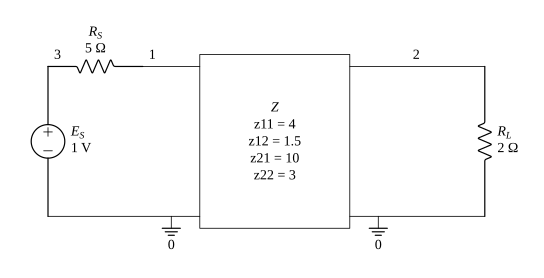

In [23]:
c11 = '''
es,3,0,1
rs,3,1,5
rl,2,0,2
z,1,2,[4,1.5,10,3]
'''
draw(c11)

In [24]:
r11 = dc(c11)
r11.rounded(4)

Result(domain='dc')
  i_es = -0.1667
  i_rl = 0.3333
  i_rs = 0.1667
  i_z1 = 0.1667
  i_z2 = -0.3333
  p_es = -0.1667
  p_rl = 0.2222
  p_rs = 0.1389
  r_es = 6.000
  v_1 = 0.1667
  v_2 = 0.6667
  v_3 = 1.000
  v_es = 1.000
  v_rl = 0.6667
  v_rs = 0.8333

## 12. An h-parameter model with a resistor under its common terminal

A transistor stage by its hybrid parameters (hie 1 k, hre 2.5e-4, hfe 100, hoe 25 uS), driven by 10 mV through 1 k and loaded by 2 k, with a 100 ohm resistor under its common terminal. In this problem, we describe a two-port with all four terminals for the first time: each port is a pair, and both pairs share node 3. v4 = -0.1645 V, a gain of -16.45; the currents into the block are ih2 = 0.8657 uA, ih4 = 82.25 uA and ih3 = -83.12 uA at the common terminal, the sum of the other two leaving. With the common terminal grounded instead (h,2,4,[...], no re) the gain is -97.56: emitter degeneration costs a factor of six.

![The circuit of An h-parameter model with a resistor under its common terminal](https://learn.symbulator.com/assets/circuit/sym_h_common_terminal.png)

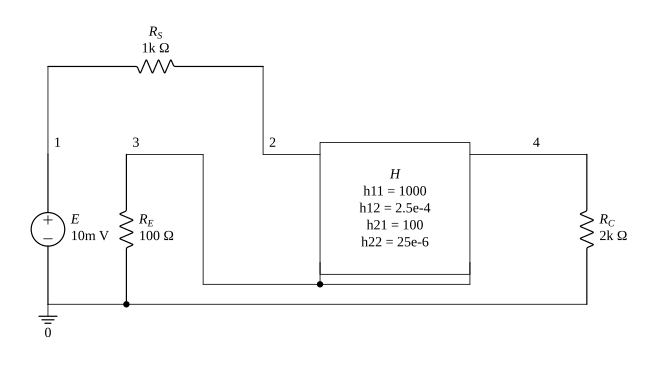

In [25]:
c12 = '''
e,1,0,0.01
rs,1,2,1000
h,[2,3],[4,3],[1000,2.5e-4,100,25e-6]
re,3,0,100
rc,4,0,2000
'''
draw(c12)

In [26]:
r12 = dc(c12)
r12.rounded(4)

Result(domain='dc')
  i_e = -8.657E-7
  i_h2 = 8.657E-7
  i_h3 = -0.00008312
  i_h4 = 0.00008225
  i_rc = -0.00008225
  i_re = 0.00008312
  i_rs = 8.657E-7
  p_e = -8.657E-9
  p_rc = 0.00001353
  p_re = 6.909E-7
  p_rs = 7.495E-10
  r_e = 1.155E+4
  v_1 = 0.01000
  v_2 = 0.009134
  v_3 = 0.008312
  v_4 = -0.1645
  v_e = 0.01000
  v_rc = -0.1645
  v_re = 0.008312
  v_rs = 0.0008657

## 13. A z-block with its second port lifted off ground

Port 1 is the pair [1,0], grounded as before; port 2 is the pair [2,3], its lower terminal reaching ground through 20 ohm. iz1 = 27/268, iz2 = -1/134 and iz3 = 1/134: the second port's current leaves the block at node 2, goes down through the load to ground and comes back up through the 20 ohm resistor into node 3, which sits below ground at v3 = -10/67 V.

![The circuit of A z-block with its second port lifted off ground](https://learn.symbulator.com/assets/circuit/sym_z_lifted_port.png)

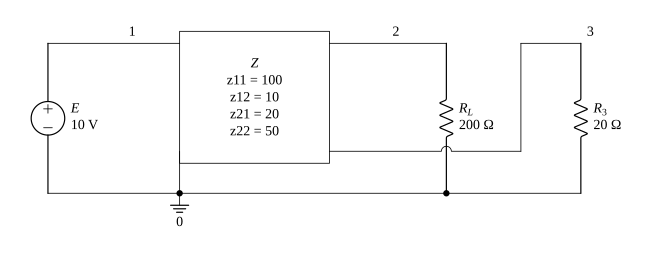

In [27]:
c13 = '''
e,1,0,10
z,[1,0],[2,3],[100,10,20,50]
rl,2,0,200
r3,3,0,20
'''
draw(c13)

In [28]:
r13 = dc(c13)
r13.rounded(4)

Result(domain='dc')
  i_e = -0.1007
  i_r3 = -0.007463
  i_rl = 0.007463
  i_z1 = 0.1007
  i_z2 = -0.007463
  i_z3 = 0.007463
  p_e = -1.007
  p_r3 = 0.001114
  p_rl = 0.01114
  r_e = 99.26
  v_1 = 10
  v_2 = 1.493
  v_3 = -0.1493
  v_e = 10
  v_r3 = -0.1493
  v_rl = 1.493

## 14. AS7's Problem 19.2

Find the z parameters of the ladder. Neither port has a grounded terminal -- the lower rail carries resistors too -- so each port is written as a pair, [a,f] and [e,j], in the node boxes. z11 = z22 = 41/15 = 2.733 ohm and z12 = z21 = 1/15 = 0.06667 ohm. Grounding both bottoms instead shorts out the lower rail and gives a different circuit's answer, 11/5 and 3/5.

The network has no node 0 at all; the tool takes each port's lower terminal as its reference for the measurement, which is what the definition of the parameters does.

![The circuit of AS7's Problem 19.2](https://learn.symbulator.com/assets/circuit/sym_as7_p1902.png)

In [29]:
c14 = '''
r1,a,b,1
r2,b,c,1
r3,c,d,1
r4,d,e,1
r5,f,g,1
r6,g,h,1
r7,h,i,1
r8,i,j,1
r9,b,g,1
r10,c,h,1
r11,d,i,1
'''

In [30]:
r14 = port(c14, '[a,f]', '[e,j]', 'z', domain='dc')
r14

PortResult('z', 11=41/15, 12=1/15, 21=1/15, 22=41/15)

## 15. AS7's Problem 19.19

Find the y parameters in s. Port 2 is the pair of junctions, port 1 the pair of outer ends, and neither is grounded. y11 = 1/2 S, y12 = y21 = -1/2 S and y22 = s + 1/2 + 1/s S -- the capacitor and inductor in parallel, plus the two ohms in series through the shorted port 1.

![The circuit of AS7's Problem 19.19](https://learn.symbulator.com/assets/circuit/sym_as7_p1919.png)

In [31]:
c15 = '''
r1,a,x,1
r2,f,y,1
c,x,y,1
l,x,y,1
'''

In [32]:
r15 = port(c15, '[a,f]', '[x,y]', 'y', domain='fd')
r15

PortResult('y', 11=1/2, 12=-1/2, 21=-1/2, 22=s + 1/2 + 1/s)

## 16. AS7's Problem 19.70

Two z-parameter blocks in a parallel-series connection: the inputs share the pair [p,0], block A's lower output terminal m is block B's upper one, and the output port is q to n. Find the g parameters: g11 = 0.06 S, g12 = -1.3, g21 = 0.7 and g22 = 23.5 ohm, which is the sum of the two blocks' own g matrices, as the parallel-series rule says.

The output side has no path to node 0 -- a block conducts nothing across its ports -- so the tool takes n as that side's reference. Solve the same description with a source at p and the answers say so in a note.

![The circuit of AS7's Problem 19.70](https://learn.symbulator.com/assets/circuit/sym_as7_p1970.png)

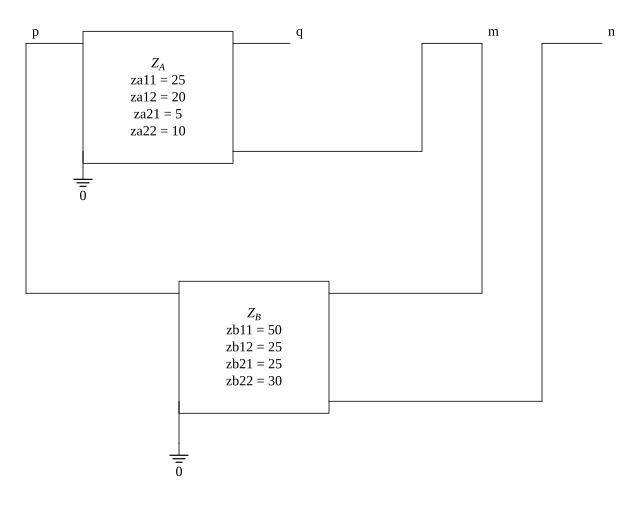

In [33]:
c16 = '''
za,[p,0],[q,m],[25,20,5,10]
zb,[p,0],[m,n],[50,25,25,30]
'''
draw(c16)

In [34]:
r16 = port(c16, 'p', '[q,n]', 'g', domain='dc')
r16

PortResult('g', 11=3/50, 12=-13/10, 21=7/10, 22=47/2)

## 17. AS7's Problem 19.17

A lattice: 8 ohm across the top, 12 across the bottom, 4 and 16 on the diagonals. Both ports float, so they are the pairs [a,f] and [c,d]. z11 = 48/5 = 9.6 ohm (the two paths from a to f, 24 and 16, in parallel), z22 = 42/5 = 8.4 ohm, z12 = z21 = -4/5 = -0.8 ohm. Ask for y instead and the four are 0.105 S, 0.01 S, 0.01 S and 0.12 S -- the inverse of the z matrix, as they must be.

![The circuit of AS7's Problem 19.17](https://learn.symbulator.com/assets/circuit/sym_as7_p1917.png)

In [35]:
c17 = '''
r8,a,c,8
r12,f,d,12
r4,a,d,4
r16,f,c,16
'''

In [36]:
r17 = port(c17, '[a,f]', '[c,d]', 'z', domain='dc')
r17

PortResult('z', 11=48/5, 12=-4/5, 21=-4/5, 22=42/5)

## 18. AS7's Problem 19.63

An ideal 1:3 transformer with 4 ohm across its primary and 9 ohm across its secondary; the ports are the two windings' own terminal pairs, neither grounded. z11 = 4/5 = 0.8 ohm (4 in parallel with the 9 referred to the primary, 9/9 = 1), z22 = 36/5 = 7.2 ohm (9 in parallel with 4 referred to the secondary, 36), and z12 = z21 = 12/5 = 2.4 ohm.

Each side is an island of its own -- a transformer conducts nothing across -- so the tool takes b and d as the two references.

![The circuit of AS7's Problem 19.63](https://learn.symbulator.com/assets/circuit/sym_as7_p1963.png)

In [37]:
c18 = '''
r4,a,b,4
t,[a,b],[c,d],[1,3]
r9,c,d,9
'''

In [38]:
r18 = port(c18, '[a,b]', '[c,d]', 'z', domain='dc')
r18

PortResult('z', 11=4/5, 12=12/5, 21=12/5, 22=36/5)

## 19. AS7's Problem 19.71

The network of Figure 19.118 as read from the drawing: the upper-left terminal t1 feeds the 8 ohm and, through the 4 ohm, the node p where the 10 ohm, the 5 ohm and the primary's top meet; the lower-left terminal is q, the foot of the 5 ohm, which reaches the primary's bottom r through the 2 ohm; the 1:2 secondary runs from the upper-right terminal t2, beyond the 6 ohm, to the lower-right terminal b2. z11 = 91/11 = 8.273 ohm, z12 = z21 = 10 ohm, z22 = 28 ohm.

![The circuit of AS7's Problem 19.71](https://learn.symbulator.com/assets/circuit/sym_as7_p1971.png)

In [39]:
c19 = '''
r8,t1,j,8
r10,j,p,10
r4,t1,p,4
r5,p,q,5
r2,q,r,2
r6,j,t2,6
t,[p,r],[t2,b2],[1,2]
'''

In [40]:
r19 = port(c19, '[t1,q]', '[t2,b2]', 'z', domain='dc')
r19

PortResult('z', 11=91/11, 12=10, 21=10, 22=28)